In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Prerequisite Information:
Disk & holder diameters to calculate moments of inertia. We model both the holder and the disk as cylinders with $I = \frac{1}{8} md^2$. We took the mass of the disk to be 20 grams with 1 gram of precision error and of the holder to be 50 grams with 1 gram of precision error.

In [2]:
# Disk Diameter (mm)
data_inertia = {
    'Disk Diameter':[31.70,31.68,31.70,31.70,31.70],
    'Mass Holder Diameter':[31.58,31.58,31.60,31.58,31.60]
}
df_inertia = pd.DataFrame(data_inertia)
df_inertia.index += 1 # Index number is now trial number
print(df_inertia)
caliper_precision_error = 0.02
error_disk_diameter = max(df_inertia['Disk Diameter'].sem(), caliper_precision_error)
error_holder_diameter = max(df_inertia['Mass Holder Diameter'].sem(), caliper_precision_error)
mean_disk_diameter = df_inertia['Disk Diameter'].mean()
mean_holder_diameter = df_inertia['Mass Holder Diameter'].mean()
print(f'Disk Diameter: {mean_disk_diameter:.2f} +- {error_disk_diameter:.2f}')
print(f'Holder Diameter: {mean_holder_diameter.mean():.2f} +- {error_holder_diameter:.2f}')

   Disk Diameter  Mass Holder Diameter
1          31.70                 31.58
2          31.68                 31.58
3          31.70                 31.60
4          31.70                 31.58
5          31.70                 31.60
Disk Diameter: 31.70 +- 0.02
Holder Diameter: 31.59 +- 0.02


We now calculate moments of inertia and their respective errors.

In [3]:
I_holder = 0.125 * 50 * (mean_holder_diameter**2)
I_holder_error = I_holder * np.sqrt(4*(error_holder_diameter/mean_holder_diameter)**2
                                    +(1/50)**2)
I_disk = 0.125 * 20 * (mean_disk_diameter**2)
I_disk_error = I_holder * np.sqrt(4*(error_disk_diameter/mean_disk_diameter)**2
                                    +(1/20)**2)
print(f'I_Disk: {I_disk:.2f} +- {I_disk_error:.2f}')
print(f'I_Holder: {I_holder:.2f} +- {I_holder_error:.2f}')

I_Disk: 2511.59 +- 311.91
I_Holder: 6236.26 +- 124.97


# Experiment:
We find the time for 10 periods in seconds for various masses. See report for full information.

In [4]:
# Number of Disks vs Oscillation Time for 10 periods (s)
data_oscillations = {
    0:[12.39,12.27,12.23,12.15,12.36],
    1:[15.03,15.23,15.14,15.05,15.30],
    3:[19.33,19.14,19.81,19.60,19.38],
    5:[22.72,23.14,22.64,22.90,22.90],
    7:[26.05,26.55,26.32,25.72,26.38],
    9:[29.15,28.57,28.52,28.49,28.30]
}
df_oscillations = pd.DataFrame(data_oscillations)
df_oscillations.index += 1 # The index number is the trial number
print(df_oscillations)
ten_period_averages = np.array([df_oscillations[x].mean() for x in range(10) if (x == 0 or x % 2 == 1)])
ten_period_errors = np.array([max(df_oscillations[x].sem(),0.01) for x in range(10) if (x == 0 or x % 2 == 1)])
print(f'With 0 Disks: {ten_period_averages[0]:.2f} +- {ten_period_errors[0]:.2f} s \n')
for i in range(1,6):
    print(f'With {i*2 - 1} Disks: {ten_period_averages[i]:.2f} +- {ten_period_errors[i]:.2f} s \n')

       0      1      3      5      7      9
1  12.39  15.03  19.33  22.72  26.05  29.15
2  12.27  15.23  19.14  23.14  26.55  28.57
3  12.23  15.14  19.81  22.64  26.32  28.52
4  12.15  15.05  19.60  22.90  25.72  28.49
5  12.36  15.30  19.38  22.90  26.38  28.30
With 0 Disks: 12.28 +- 0.04 s 

With 1 Disks: 15.15 +- 0.05 s 

With 3 Disks: 19.45 +- 0.12 s 

With 5 Disks: 22.86 +- 0.09 s 

With 7 Disks: 26.20 +- 0.15 s 

With 9 Disks: 28.61 +- 0.14 s 



# Analysis:
We hope to find $\kappa$ where $I = T^2 \left(\frac{\kappa^2}{4\pi^2}\right)$. We thus perform linear regression predicting $I$ as a function of $T^2$, as this will have slope $\frac{\kappa^2}{4\pi^2}$. Setting up our necessary dataframe with errors:

In [5]:
moments_of_inertia = np.array([I_holder + x*I_disk for x in range(10) if (x==0 or x%2==1)])
moments_of_inertia_errors = np.sqrt(np.array([(I_holder_error)**2 + (x*I_disk_error)**2 for x in range(10) if (x==0 or x%2==1)]))
periods_squared = (ten_period_averages/10)**2
periods_squared_errors = periods_squared*(2*ten_period_errors/ten_period_averages)
data_convenience = pd.DataFrame()
data_convenience['Period-Square'] = periods_squared
data_convenience['Period-Square Errors'] = periods_squared_errors
data_convenience['Moments of Inertia'] = moments_of_inertia
data_convenience['MoI Errors'] = moments_of_inertia_errors
data_convenience.index = data_convenience.index*2 - 1
data_convenience.rename(index={-1:0},inplace=True) # Index Number is now Number of Disks
print(data_convenience)

   Period-Square  Period-Square Errors  Moments of Inertia   MoI Errors
0       1.507984              0.010705          6236.26090   124.974968
1       2.295225              0.015657          8747.85194   336.017940
3       3.783803              0.044991         13771.03402   944.045848
5       5.225796              0.039542         18794.21610  1564.561145
7       6.866496              0.076138         23817.39818  2186.960242
9       8.183032              0.082087         28840.58026  2809.991659


A scatterplot with error bars is given below.

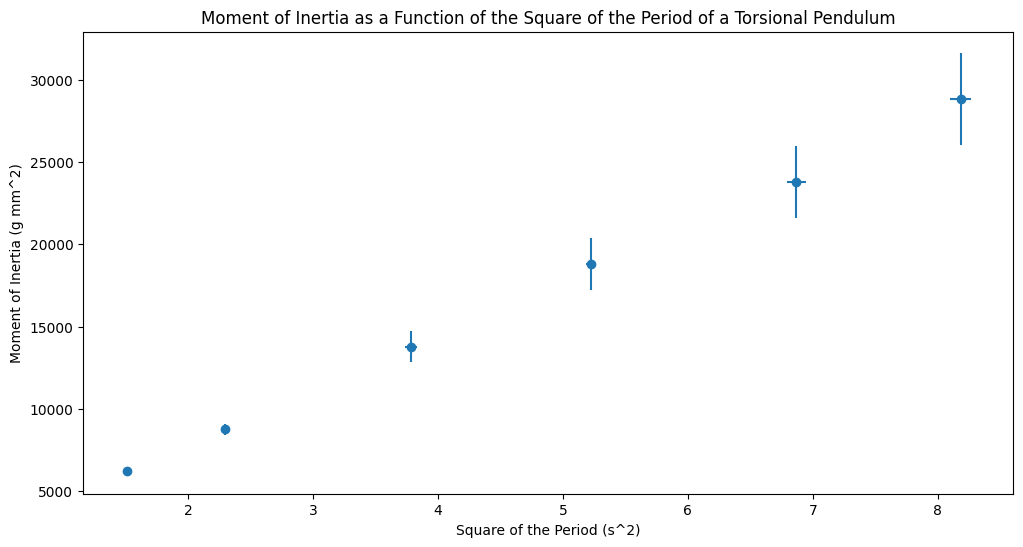

In [6]:
plt.figure(figsize=(12,6))
plt.errorbar(x=periods_squared, y=moments_of_inertia,xerr=periods_squared_errors,yerr=moments_of_inertia_errors,fmt='o')
plt.xlabel("Square of the Period (s^2)")
plt.ylabel("Moment of Inertia (g mm^2)")
plt.title("Moment of Inertia as a Function of the Square of the Period of a Torsional Pendulum")
plt.show()

We begin by performing an OLS regression with error in both directions.

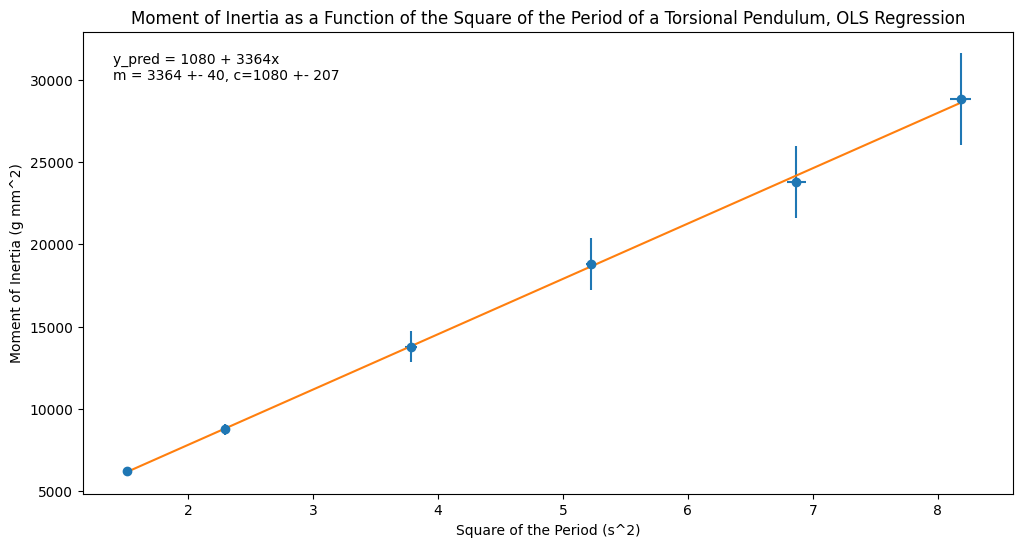

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     7161.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.17e-07
Time:                        15:37:01   Log-Likelihood:                -39.963
No. Observations:                   6   AIC:                             83.93
Df Residuals:                       4   BIC:                             83.51
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1080.4223    207.373      5.210      0.0

C:\Users\vijay\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [10]:
y = moments_of_inertia
X = periods_squared
X = sm.add_constant(X)
N = moments_of_inertia.size # Techincally also periods_squared.size just the number of observations
ols_model = sm.OLS(y,X)
ols_results = ols_model.fit()
alpha_cu = np.sqrt(np.sum(((y - ols_results.predict()))**2)/(N-2))
delta = N * np.sum(periods_squared**2) - (np.sum(periods_squared))**2
alpha_m_ols = alpha_cu * np.sqrt(N/delta)
alpha_c_ols = alpha_cu * np.sqrt(np.sum(periods_squared**2)/delta)
plt.figure(figsize=(12,6))
plt.errorbar(x=periods_squared, y=moments_of_inertia,xerr=periods_squared_errors,yerr=moments_of_inertia_errors,fmt='o')
plt.xlabel("Square of the Period (s^2)")
plt.ylabel("Moment of Inertia (g mm^2)")
plt.title("Moment of Inertia as a Function of the Square of the Period of a Torsional Pendulum, OLS Regression")
plt.plot(periods_squared, ols_results.predict())
plt.text(1.4, 31000, f'y_pred = {ols_results.params[0]:.0f} + {ols_results.params[1]:.0f}x')
plt.text(1.4, 30000, f'm = {ols_results.params[1]:.0f} +- {alpha_m_ols:.0f}, c={ols_results.params[0]:.0f} +- {alpha_c_ols:.0f}')

plt.show()
print(ols_results.summary())

Now we proceed to a weighted least squares regression. To do so, we must first develop adjusted errors for our y-values so we may neglect the errors in our x-values:
$$\alpha_{adj.i} = \sqrt{\alpha_{y,i}^2 + (m\alpha_{x,i})^2}$$
where $m$ is the slope achieved in an OLS regression.

In [11]:
adjusted_moi_errors = np.sqrt(moments_of_inertia_errors**2 + (ols_results.params[1]*periods_squared_errors)**2)
data_convenience['Adjusted MoI Errors'] = adjusted_moi_errors
print(data_convenience[['Period-Square', 'Moments of Inertia', 'Adjusted MoI Errors']])

   Period-Square  Moments of Inertia  Adjusted MoI Errors
0       1.507984          6236.26090           130.059896
1       2.295225          8747.85194           340.120312
3       3.783803         13771.03402           956.100008
5       5.225796         18794.21610          1570.205092
7       6.866496         23817.39818          2201.906166
9       8.183032         28840.58026          2823.526109


We now conduct a weighted least squares regression. We define $\Delta_{WLS}$ to be $\sum w_i \sum w_ix_i^2 - \left(\sum w_i x_i \right)^2$ to have $$\alpha_m = \sqrt{\frac{\sum w_i}{\Delta_{WLS}}} \phantom{mmmm} \alpha_c = \sqrt{\frac{\sum w_i x_i^2}{\Delta_{WLS}}}$$

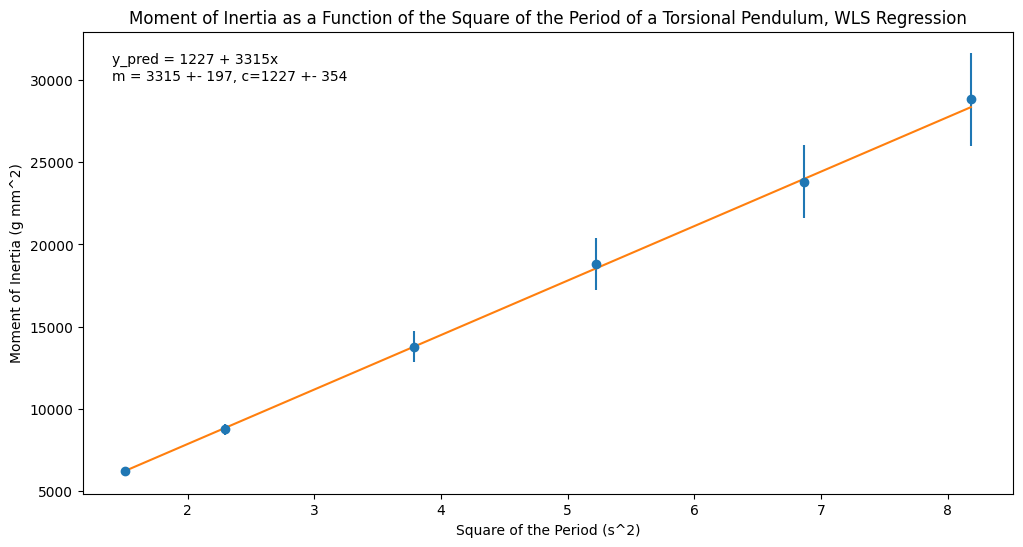

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            WLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     8538.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           8.22e-08
Time:                        15:54:36   Log-Likelihood:                -37.645
No. Observations:                   6   AIC:                             79.29
Df Residuals:                       4   BIC:                             78.87
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1227.0428     64.480     19.030      0.0

C:\Users\vijay\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [16]:
weights_wls = 1/(adjusted_moi_errors**2)
wls_model = sm.WLS(y,X,weights=weights_wls)
wls_results = wls_model.fit()
wls_delta = (np.sum(weights_wls) * np.sum(weights_wls * (periods_squared**2))) - ((np.sum(weights_wls * periods_squared))**2)
alpha_m_wls = np.sqrt(np.sum(weights_wls)/wls_delta)
alpha_c_wls = np.sqrt(np.sum(weights_wls * (periods_squared)**2)/wls_delta)
plt.figure(figsize=(12,6))
plt.errorbar(x=periods_squared, y=moments_of_inertia,yerr=adjusted_moi_errors,fmt='o')
plt.xlabel("Square of the Period (s^2)")
plt.ylabel("Moment of Inertia (g mm^2)")
plt.title("Moment of Inertia as a Function of the Square of the Period of a Torsional Pendulum, WLS Regression")
plt.plot(periods_squared, wls_results.predict())
plt.text(1.4, 31000, f'y_pred = {wls_results.params[0]:.0f} + {wls_results.params[1]:.0f}x')
plt.text(1.4, 30000, f'm = {wls_results.params[1]:.0f} +- {alpha_m_wls:.0f}, c={wls_results.params[0]:.0f} +- {alpha_c_wls:.0f}')
plt.show()
print(wls_results.summary())

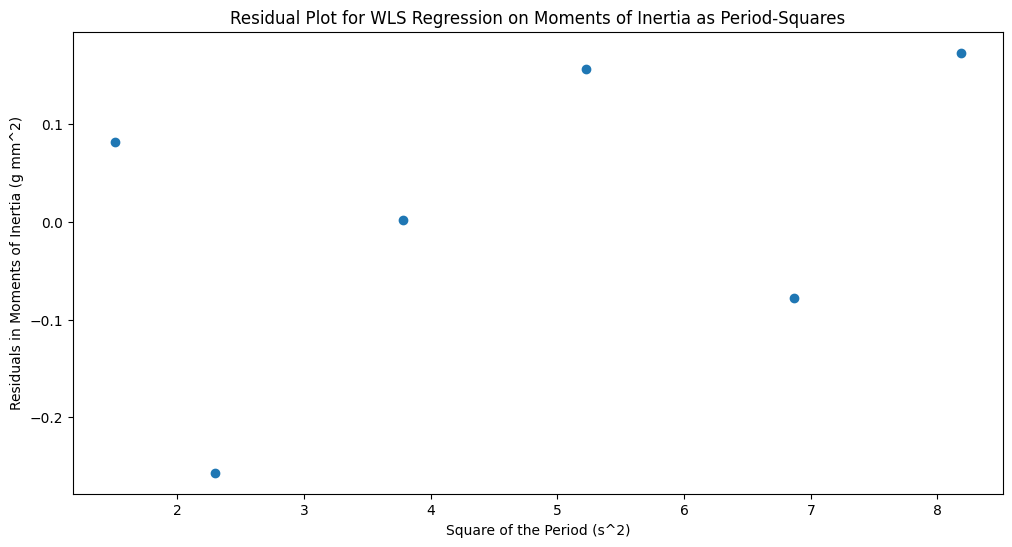

In [18]:
wls_residuals = (y - wls_results.predict())/adjusted_moi_errors
plt.figure(figsize=(12,6))
plt.scatter(x=periods_squared, y=wls_residuals)
plt.xlabel("Square of the Period (s^2)")
plt.ylabel("Residuals in Moments of Inertia (g mm^2)")
plt.title("Residual Plot for WLS Regression on Moments of Inertia as Period-Squares")
plt.show()

Calculating $\kappa$:

In [36]:
kappa = 4 * np.pi**2 * wls_results.params[1]
kappa_error = 4 * np.pi**2 * alpha_m_wls
print(f'Slope: {wls_results.params[1]:.0f} +- {alpha_m_wls:.0f}')
print(f'Kappa: {kappa:.0f} +- {kappa_error:.0f}')

Slope: 3315 +- 197
Kappa: 130861 +- 7771


Now we finish with a $\chi^2$ analysis, where $$\chi^2 = \sum w_i (y_i - mx_i - c)^2$$

In [23]:
chi_sq = np.sum(weights_wls * (wls_residuals)**2)
print(f'Chi-Squared: {chi_sq}')
chi_sq_eff = chi_sq/(N-2)
print(f'Chi-Squared Effective: {chi_sq_eff}')

Chi-Squared: 9.782350040315265e-07
Chi-Squared Effective: 2.445587510078816e-07


Comparing our value to the accepted value of $\kappa$:

In [38]:
wire_length = 200 # we measured it to be 20cm
wire_radius = 0.3211/2
shear_modulus = 46.4*(10**9) # 10**9 g/(mm*s^2) in 1 GPa
accepted_value = np.pi * shear_modulus * (wire_radius**4)/(2*wire_length)
print(accepted_value)

242130.2784852665


Finding error bounds for this value:

In [40]:
length_error = 0.5
radius_error = 0.02
shear_modulus_error = 0.825*(10**9)
accepted_value_error = accepted_value * np.sqrt((shear_modulus_error/shear_modulus)**2 + (4*radius_error/wire_radius)**2 + (length_error/wire_length)**2)
print(f'{accepted_value} +- {accepted_value_error}')

242130.2784852665 +- 120728.70545601367


In [42]:
epsilon = abs(kappa - accepted_value)
alpha_epsilon = np.sqrt(kappa_error**2 + accepted_value_error**2)
print(f'epsilon: {epsilon}, alpha_epsilon: {alpha_epsilon}')

epsilon: 111268.83375802192, alpha_epsilon: 120978.56875071162
